In [2]:
import pdfplumber
print(pdfplumber.__version__)

0.11.9


In [3]:
report = pdfplumber.open("./sample.pdf").pages[0]

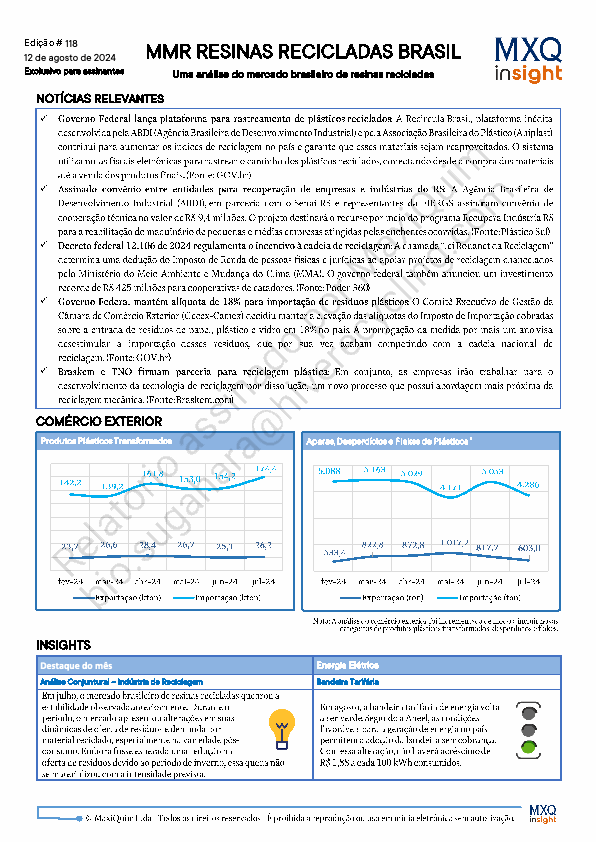

In [20]:
im = report.to_image()
im


In [21]:
im.draw_rects(report.extract_words)

TypeError: 'method' object is not iterable

In [5]:
tables = report.find_tables()
print(f"Found {len(tables)} tables.")

Found 5 tables.


In [6]:
table = report.extract_table()
table[:100]

[['', '', '', '', '', ''],
 ['', '', '', '', '', ''],
 ['', '', '', '', '', ''],
 ['', '', '', '', '', ''],
 ['', '', '', '', '', ''],
 ['', '', '', '', '', ''],
 ['', '', '', '', '', ''],
 ['', '', '', '', '', '']]

In [18]:
print(report.images)

[{'x0': 529.7, 'y0': 18.573, 'x1': 555.3000000000001, 'y1': 36.823, 'width': 25.600000000000023, 'height': 18.25, 'name': 'Image9', 'stream': <PDFStream(53): raw=9275, {'Type': /'XObject', 'Subtype': /'Image', 'Width': 240, 'Height': 171, 'ColorSpace': /'DeviceRGB', 'BitsPerComponent': 8, 'Interpolate': False, 'SMask': <PDFObjRef:54>, 'Filter': /'FlateDecode', 'Length': 9275}>, 'srcsize': (240, 171), 'imagemask': None, 'bits': 8, 'colorspace': [/'DeviceRGB'], 'mcid': None, 'tag': None, 'object_type': 'image', 'page_number': 1, 'top': 805.177, 'bottom': 823.427, 'doctop': 805.177}, {'x0': 86.625, 'y0': 18.625, 'x1': 138.133, 'y1': 29.025, 'width': 51.50800000000001, 'height': 10.399999999999999, 'name': 'Image11', 'stream': <PDFStream(55): raw=2, {'Type': /'XObject', 'Subtype': /'Image', 'Width': 2, 'Height': 2, 'ColorSpace': [/'Indexed', /'DeviceRGB', 1, b'\x00\x00\x00\xff\xff\xff'], 'BitsPerComponent': 1, 'Interpolate': False, 'SMask': <PDFObjRef:56>, 'Length': 2}>, 'srcsize': (2, 2),

In [7]:
tablefinder = report.debug_tablefinder()
cells = tablefinder.cells


In [14]:
for element in report.structure_tree:
         print(element["type"], element["mcids"])
         for child in element.children:
             print(child["type"], child["mcids"])

In [9]:
report.curves

[{'x0': 37.396,
  'y0': 22.423,
  'x1': 79.503,
  'y1': 24.573,
  'width': 42.107,
  'height': 2.150000000000002,
  'pts': [(37.403, 817.427),
   (79.503, 817.577),
   (79.496, 819.577),
   (37.396, 819.427),
   (37.403, 817.427)],
  'linewidth': 2.0,
  'stroke': False,
  'fill': True,
  'evenodd': False,
  'stroking_color': (0.357, 0.608, 0.835),
  'non_stroking_color': (0.357, 0.608, 0.835),
  'mcid': None,
  'tag': None,
  'object_type': 'curve',
  'page_number': 1,
  'path': [('m', (37.403, 817.427)),
   ('l', (79.503, 817.577)),
   ('l', (79.496, 819.577)),
   ('l', (37.396, 819.427)),
   ('h',)],
  'dash': None,
  'top': 817.427,
  'bottom': 819.577,
  'doctop': 817.427},
 {'x0': 76.5,
  'y0': 20.423,
  'x1': 82.5,
  'y1': 26.423,
  'width': 6.0,
  'height': 6.0,
  'pts': [(79.511, 815.577),
   (82.5, 818.587),
   (79.489, 821.577),
   (76.5, 818.566),
   (79.511, 815.577),
   (79.511, 815.577)],
  'linewidth': 2.0,
  'stroke': False,
  'fill': True,
  'evenodd': False,
  'stroki

In [10]:
report.curves[0]

{'x0': 37.396,
 'y0': 22.423,
 'x1': 79.503,
 'y1': 24.573,
 'width': 42.107,
 'height': 2.150000000000002,
 'pts': [(37.403, 817.427),
  (79.503, 817.577),
  (79.496, 819.577),
  (37.396, 819.427),
  (37.403, 817.427)],
 'linewidth': 2.0,
 'stroke': False,
 'fill': True,
 'evenodd': False,
 'stroking_color': (0.357, 0.608, 0.835),
 'non_stroking_color': (0.357, 0.608, 0.835),
 'mcid': None,
 'tag': None,
 'object_type': 'curve',
 'page_number': 1,
 'path': [('m', (37.403, 817.427)),
  ('l', (79.503, 817.577)),
  ('l', (79.496, 819.577)),
  ('l', (37.396, 819.427)),
  ('h',)],
 'dash': None,
 'top': 817.427,
 'bottom': 819.577,
 'doctop': 817.427}

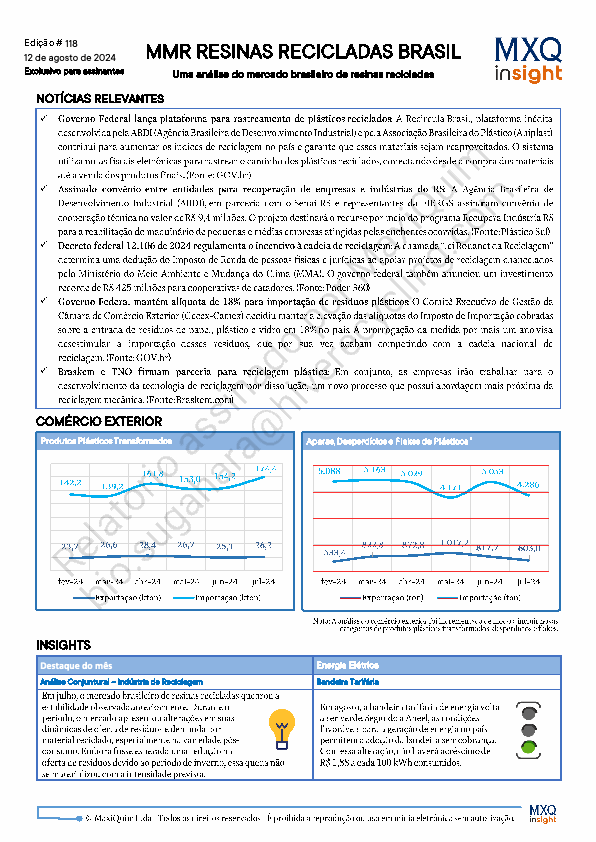

In [12]:
gridlines =  [ x for x in report.lines
    if x["width"] > 10 and x["x0"] > report.width / 2 ]

im.reset().draw_lines(gridlines)